In [1]:
import pandas as pd

df = pd.read_csv("student_lifestyle_dataset.csv")

In [2]:
df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [4]:
#data exploration
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

#missing values 
print("\nMissing Values Per Column:")
print(df.isna().sum())

if df.isna().sum().sum() == 0:
    print("\nThere are no missing values in the dataset.")

#duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (2000, 8)

Column Names:
['Student_ID', 'Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'GPA', 'Stress_Level']

Data Types:
Student_ID                           int64
Study_Hours_Per_Day                float64
Extracurricular_Hours_Per_Day      float64
Sleep_Hours_Per_Day                float64
Social_Hours_Per_Day               float64
Physical_Activity_Hours_Per_Day    float64
GPA                                float64
Stress_Level                        object
dtype: object

Missing Values Per Column:
Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
dtype: int64

There are no missing values in the dataset.

Duplicate Rows: 0


In [13]:
#import libraries
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
!pip install dash 
from dash import Dash, dcc, html, Input, Output


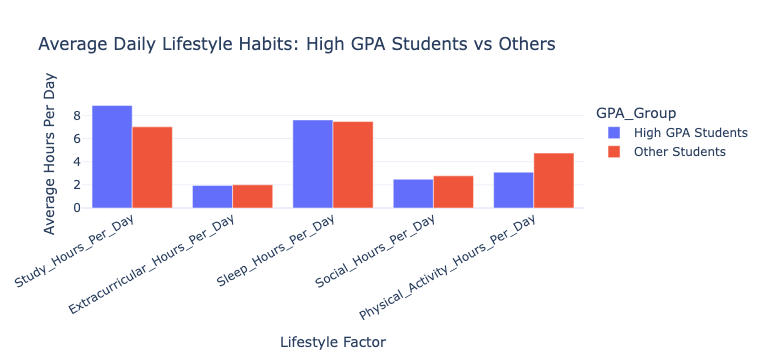

In [10]:
#lifestyle balance of low vs high GPA
df["GPA_Group"] = np.where(df["GPA"] >= df["GPA"].quantile(0.75), "High GPA Students", "Other Students")

lifestyle_cols = [
    "Study_Hours_Per_Day",
    "Extracurricular_Hours_Per_Day",
    "Sleep_Hours_Per_Day",
    "Social_Hours_Per_Day",
    "Physical_Activity_Hours_Per_Day"
]

balance_df = df.groupby("GPA_Group")[lifestyle_cols].mean().reset_index()

balance_long = balance_df.melt(
    id_vars="GPA_Group",
    value_vars=lifestyle_cols,
    var_name="Lifestyle Factor",
    value_name="Average Hours Per Day"
)

fig3 = px.bar(
    balance_long,
    x="Lifestyle Factor",
    y="Average Hours Per Day",
    color="GPA_Group",
    barmode="group",
    title="Average Daily Lifestyle Habits: High GPA Students vs Others",
    template="plotly_white"
)

fig3.update_layout(xaxis_tickangle=-30)

fig3.show()

### ⚖️ Lifestyle Balance: High GPA Students vs Others

This grouped bar chart compares the average daily time allocation across key lifestyle activities between high-performing students (top 25% GPA) and all other students.

The visualization reveals that high GPA students tend to maintain a more balanced distribution of time across studying, sleep, and physical activity. While they may study slightly more on average, they do not significantly sacrifice sleep or other important activities.

In contrast, lower GPA students may exhibit less optimal time allocation, such as reduced study time or imbalanced lifestyle habits.

This chart supports the idea that academic success is not driven solely by maximizing study time, but rather by achieving a balanced routine that includes adequate sleep, physical activity, and controlled social time.

It provides strong evidence that the most effective strategy for maximizing GPA involves optimizing lifestyle balance rather than focusing on a single factor.

In [26]:
lifestyle_factors = {
    "Study Hours": "Study_Hours_Per_Day",
    "Sleep Hours": "Sleep_Hours_Per_Day",
    "Social Hours": "Social_Hours_Per_Day",
    "Extracurricular Hours": "Extracurricular_Hours_Per_Day",
    "Physical Activity Hours": "Physical_Activity_Hours_Per_Day"
}

card_style = {
    "backgroundColor": "white",
    "padding": "20px",
    "borderRadius": "12px",
    "boxShadow": "0 2px 8px rgba(0,0,0,0.1)",
    "width": "230px",
    "textAlign": "center"
}

insight_style = {
    "backgroundColor": "white",
    "padding": "15px",
    "borderRadius": "10px",
    "boxShadow": "0 2px 8px rgba(0,0,0,0.08)",
    "fontSize": "15px",
    "lineHeight": "1.5"
}

def get_best_range(df, factor, bins=10):
    temp = df.copy()
    temp["bin"] = pd.cut(temp[factor], bins=bins)
    grouped = temp.groupby("bin", observed=False)["GPA"].mean().reset_index()
    best_row = grouped.loc[grouped["GPA"].idxmax()]
    return f"{best_row['bin'].left:.1f}–{best_row['bin'].right:.1f} hrs"

best_study_range = get_best_range(df, "Study_Hours_Per_Day")
best_sleep_range = get_best_range(df, "Sleep_Hours_Per_Day")
best_activity_range = get_best_range(df, "Physical_Activity_Hours_Per_Day")

best_stress_level = df.groupby("Stress_Level")["GPA"].mean().idxmax()

def create_binned_line(df, selected_factor, bins=10):
    temp = df.copy()
    temp["bin"] = pd.cut(temp[selected_factor], bins=bins)

    grouped = temp.groupby("bin", observed=False)["GPA"].mean().reset_index()
    grouped["bin_center"] = grouped["bin"].apply(lambda x: x.mid)
    grouped = grouped.sort_values("bin_center")

    best_row = grouped.loc[grouped["GPA"].idxmax()]
    best_x = best_row["bin_center"]
    best_y = best_row["GPA"]
    best_range = best_row["bin"]

    fig = px.line(
        grouped,
        x="bin_center",
        y="GPA",
        markers=True,
        title=f"Average GPA Across {selected_factor.replace('_', ' ')}",
        labels={
            "bin_center": selected_factor.replace("_", " "),
            "GPA": "Average GPA"
        },
        template="plotly_white"
    )

    fig.add_scatter(
        x=[best_x],
        y=[best_y],
        mode="markers+text",
        marker=dict(size=16, symbol="star"),
        text=["Optimal Range"],
        textposition="top center",
        name="Highest Avg GPA"
    )

    fig.add_annotation(
        x=best_x,
        y=best_y,
        text=f"Best range: {best_range}<br>Avg GPA: {best_y:.2f}",
        showarrow=True,
        arrowhead=2,
        ax=40,
        ay=-60,
        bgcolor="white",
        bordercolor="black",
        borderwidth=1
    )

    fig.update_layout(title_x=0.5, height=600)
    return fig

def create_lifestyle_comparison(df):
    temp_df = df.copy()
    high_gpa_cutoff = temp_df["GPA"].quantile(0.75)

    temp_df["GPA_Group"] = temp_df["GPA"].apply(
        lambda x: "High GPA Students" if x >= high_gpa_cutoff else "Other Students"
    )

    lifestyle_cols = [
        "Study_Hours_Per_Day",
        "Sleep_Hours_Per_Day",
        "Social_Hours_Per_Day",
        "Physical_Activity_Hours_Per_Day",
        "Extracurricular_Hours_Per_Day"
    ]

    grouped = temp_df.groupby("GPA_Group")[lifestyle_cols].mean().reset_index()

    grouped_long = grouped.melt(
        id_vars="GPA_Group",
        var_name="Lifestyle Factor",
        value_name="Average Hours Per Day"
    )

    grouped_long["Lifestyle Factor"] = (
        grouped_long["Lifestyle Factor"]
        .str.replace("_Hours_Per_Day", "", regex=False)
        .str.replace("_", " ")
    )

    fig = px.bar(
        grouped_long,
        x="Lifestyle Factor",
        y="Average Hours Per Day",
        color="GPA_Group",
        barmode="group",
        title="Lifestyle Habits: High GPA Students vs Other Students",
        labels={
            "Lifestyle Factor": "Lifestyle Factor",
            "Average Hours Per Day": "Average Hours Per Day",
            "GPA_Group": "GPA Group"
        },
        template="plotly_white"
    )

    fig.update_layout(title_x=0.5, xaxis_tickangle=-25, height=500)
    return fig

def create_stress_sleep_tradeoff(df):
    temp = df.copy()

    stress_order = ["Low", "Moderate", "High"]

    grouped = (
        temp.groupby("Stress_Level")
        .agg(
            Average_GPA=("GPA", "mean"),
            Average_Sleep=("Sleep_Hours_Per_Day", "mean"),
            Average_Study=("Study_Hours_Per_Day", "mean"),
            Student_Count=("Student_ID", "count")
        )
        .reset_index()
    )

    grouped["Stress_Level"] = pd.Categorical(
        grouped["Stress_Level"],
        categories=stress_order,
        ordered=True
    )

    grouped = grouped.sort_values("Stress_Level")

    fig = px.scatter(
        grouped,
        x="Average_Sleep",
        y="Average_GPA",
        size="Student_Count",
        color="Stress_Level",
        text="Stress_Level",
        title="Tradeoff Between Sleep, Stress, and GPA",
        labels={
            "Average_Sleep": "Average Sleep Hours Per Day",
            "Average_GPA": "Average GPA",
            "Stress_Level": "Stress Level",
            "Student_Count": "Number of Students"
        },
        template="plotly_white",
        hover_data={
            "Average_Study": ":.2f",
            "Student_Count": True,
            "Average_Sleep": ":.2f",
            "Average_GPA": ":.2f"
        }
    )

    fig.update_traces(
        textposition="top center",
        marker=dict(line=dict(width=1, color="black"))
    )

    fig.update_layout(title_x=0.5, height=500)
    return fig

app = Dash(__name__)

app.layout = html.Div(
    style={
        "fontFamily": "Arial",
        "padding": "25px",
        "backgroundColor": "#f7f9fc"
    },
    children=[

        html.H1(
            "How to Maximize GPA: Lifestyle Insights Dashboard",
            style={"textAlign": "center"}
        ),

        html.P(
            "This dashboard explores which lifestyle habits are most associated with higher GPA, while also considering sleep and stress tradeoffs.",
            style={"textAlign": "center", "fontSize": "16px"}
        ),

        html.Div(
            style={
                "display": "flex",
                "justifyContent": "center",
                "gap": "20px",
                "marginTop": "25px",
                "marginBottom": "20px",
                "flexWrap": "wrap"
            },
            children=[
                html.Div([html.H3("Best Study Range"), html.H2(best_study_range)], style=card_style),
                html.Div([html.H3("Best Sleep Range"), html.H2(best_sleep_range)], style=card_style),
                html.Div([html.H3("Best Activity Range"), html.H2(best_activity_range)], style=card_style),
                html.Div([html.H3("Highest-GPA Stress Level"), html.H2(best_stress_level)], style=card_style),
            ]
        ),

        html.Div(
            style={**insight_style, "width": "85%", "margin": "auto", "marginBottom": "30px"},
            children=[
                html.H3("KPI Summary: What These Numbers Mean"),
                html.P(
                    "These KPI cards summarize the lifestyle ranges most associated with the highest average GPA in the dataset. "
                )
            ]
        ),

        dcc.Dropdown(
            id="factor-dropdown",
            options=[{"label": k, "value": v} for k, v in lifestyle_factors.items()],
            value="Study_Hours_Per_Day",
            clearable=False,
            style={
                "width": "50%",
                "margin": "auto",
                "marginBottom": "20px"
            }
        ),

        dcc.Graph(id="gpa-chart"),

        html.Div(
            id="insight-text",
            style={**insight_style, "width": "80%", "margin": "auto", "marginBottom": "30px"}
        ),

        html.Div(
            style={
                "display": "grid",
                "gridTemplateColumns": "1fr 1fr",
                "gap": "25px"
            },
            children=[
                html.Div([
                    dcc.Graph(id="lifestyle-comparison-chart"),
                    html.Div(
                        style=insight_style,
                        children=[
                            html.H3("Lifestyle Comparison Insight"),
                            html.P(
                                "This chart compares the average daily habits of high-GPA students against all other students. "
                            )
                        ]
                    )
                ]),

                html.Div([
                    dcc.Graph(id="stress-sleep-tradeoff-chart"),
                    html.Div(
                        style=insight_style,
                        children=[
                            html.H3("Sleep and Stress Tradeoff Insight"),
                            html.P(
                                "This chart shows how average sleep, stress level, and GPA relate to one another. "
                                "It helps identify whether students with higher stress also tend to sleep less and whether that tradeoff is connected to GPA. "
                            )
                        ]
                    )
                ])
            ]
        )
    ]
)

@app.callback(
    Output("gpa-chart", "figure"),
    Output("insight-text", "children"),
    Output("lifestyle-comparison-chart", "figure"),
    Output("stress-sleep-tradeoff-chart", "figure"),
    Input("factor-dropdown", "value")
)
def update_dashboard(selected_factor):

    fig_main = create_binned_line(df, selected_factor)
    fig_lifestyle = create_lifestyle_comparison(df)
    fig_tradeoff = create_stress_sleep_tradeoff(df)

    readable_name = selected_factor.replace("_", " ").lower()

    insight = html.Div([
        html.H3("Interactive GPA Factor Insight"),
        html.P(
            f"This chart shows how GPA changes across different levels of {readable_name}. "
            "The star marker identifies the range with the highest average GPA. "
        )
    ])

    return fig_main, insight, fig_lifestyle, fig_tradeoff

app.run(debug=False, port=8050)